# Entrega 3 
### Problema de abandono en banco - Kaggle 
#### Equipo: Enrique De Martini, Esteban Cardoso, Lucas Barrios  

## 0) Importar librerías y cargar el dataset de train.csv

In [1]:
# 01. IMPORTAR LIBRERIAS GENERALES ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 02. DEFINIR CONFIGURACIONES GENERALES ---

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)

In [ ]:
# 03. IMPORTAR DATASET train.csv ---

url = "https://raw.githubusercontent.com/estebancardoso96/grupo_3/main/train.csv"
df = pd.read_csv(url)

# Creamos una copia del dataframe original por si luego quiero utilizar alguna variable sin modificaciones 
copia_cruda_df = df.copy()

In [4]:
# 04. REALIZAR UNA INSPECCION INICIAL DEL DATASET train.csv ---

print("AUDITORIA DE VARIABLES DEL DATASET train.csv")

print(f"\nDimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas\n")

audit = pd.DataFrame({
    'dtype':          df.dtypes,
    'nulos':          df.isnull().sum(),
    'pct_nulos':      (df.isnull().sum() / len(df) * 100).round(2),
    'valores_únicos': df.nunique(),
    'moda':           df.mode().iloc[0], # Extrae la primera fila de la moda
    'ejemplo':        df.sample(1).iloc[0], # Genera muestra aleatoria y extrae primera fila
    })
audit

AUDITORIA DE VARIABLES DEL DATASET train.csv

Dimensiones del dataset: 15000 filas × 14 columnas



,dtype,nulos,pct_nulos,valores_únicos,moda,ejemplo
id,int64,0,0.00,15000,0,8420
CustomerId,float64,0,0.00,6309,15793331.00,15598046.00
Surname,str,0,0.00,763,Ch'iu,Ch'iu
CreditScore,float64,0,0.00,378,678.00,573.00
Geography,str,0,0.00,3,France,France
Gender,str,0,0.00,2,Male,Male
Age,float64,0,0.00,55,38.00,40.00
Tenure,float64,0,0.00,11,2.00,9.00
Balance,float64,0,0.00,3328,0.00,0.00
NumOfProducts,float64,0,0.00,4,2.00,2.00


## 1) Limpiar y ordenar las variables

In [ ]:
# 05. COMPLETAR POR GRUPOS LISTA DE VARIABLES A USAR EN EL MODELO ---

# Antes realizamos el log de 'EstimatedSalary' para que tenga una distribución más normal y no sesgada a la derecha
# Usamos log1p para evitar problemas con valores de 0, ya que log(0) no está definido
df['EstimatedSalary'] = np.log1p(df['EstimatedSalary'])

# Definimos variables numéricas a usar en el modelo
num_features = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'EstimatedSalary'
]

# Definimos variables categóricas a usar en el modelo
cat_features = [
    'Geography',
    'Gender',
    'NumOfProducts'
]

# Definimos variables binarias a usar en el modelo
bin_features = [
    'HasCrCard',
    'IsActiveMember'
]

target = 'Exited'

In [6]:
# 06. ELIMINAR COLUMNAS DEL DATASET QUE NO SE USARAN EN EL MODELO

col_eliminar =[
    'id',
    'CustomerId',
    'Surname'
]

df_depurado = df.drop(columns=col_eliminar)

## 2) Análisis exploratorio de los datos (EDA)

In [ ]:
# 07. REALIZAR ESTADISTICA DESCRIPTIVA DEL DATASET DEPURADO

# Generamos la estadística descriptiva del dataset depurado
df_depurado.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,658.13,37.74,5.00,42929.93,1.59,0.78,0.49,11.53,0.20
std,73.26,8.18,2.81,59820.61,0.53,0.41,0.50,0.69,0.40
min,431.00,18.00,0.00,0.00,1.00,0.00,0.00,2.53,0.00
25%,600.00,32.00,3.00,0.00,1.00,1.00,0.00,11.32,0.00
50%,661.00,37.00,5.00,0.00,2.00,1.00,0.00,11.72,0.00
75%,709.00,42.00,7.00,109733.20,2.00,1.00,1.00,11.96,0.00
max,850.00,72.00,10.00,206329.65,4.00,1.00,1.00,16.75,1.00


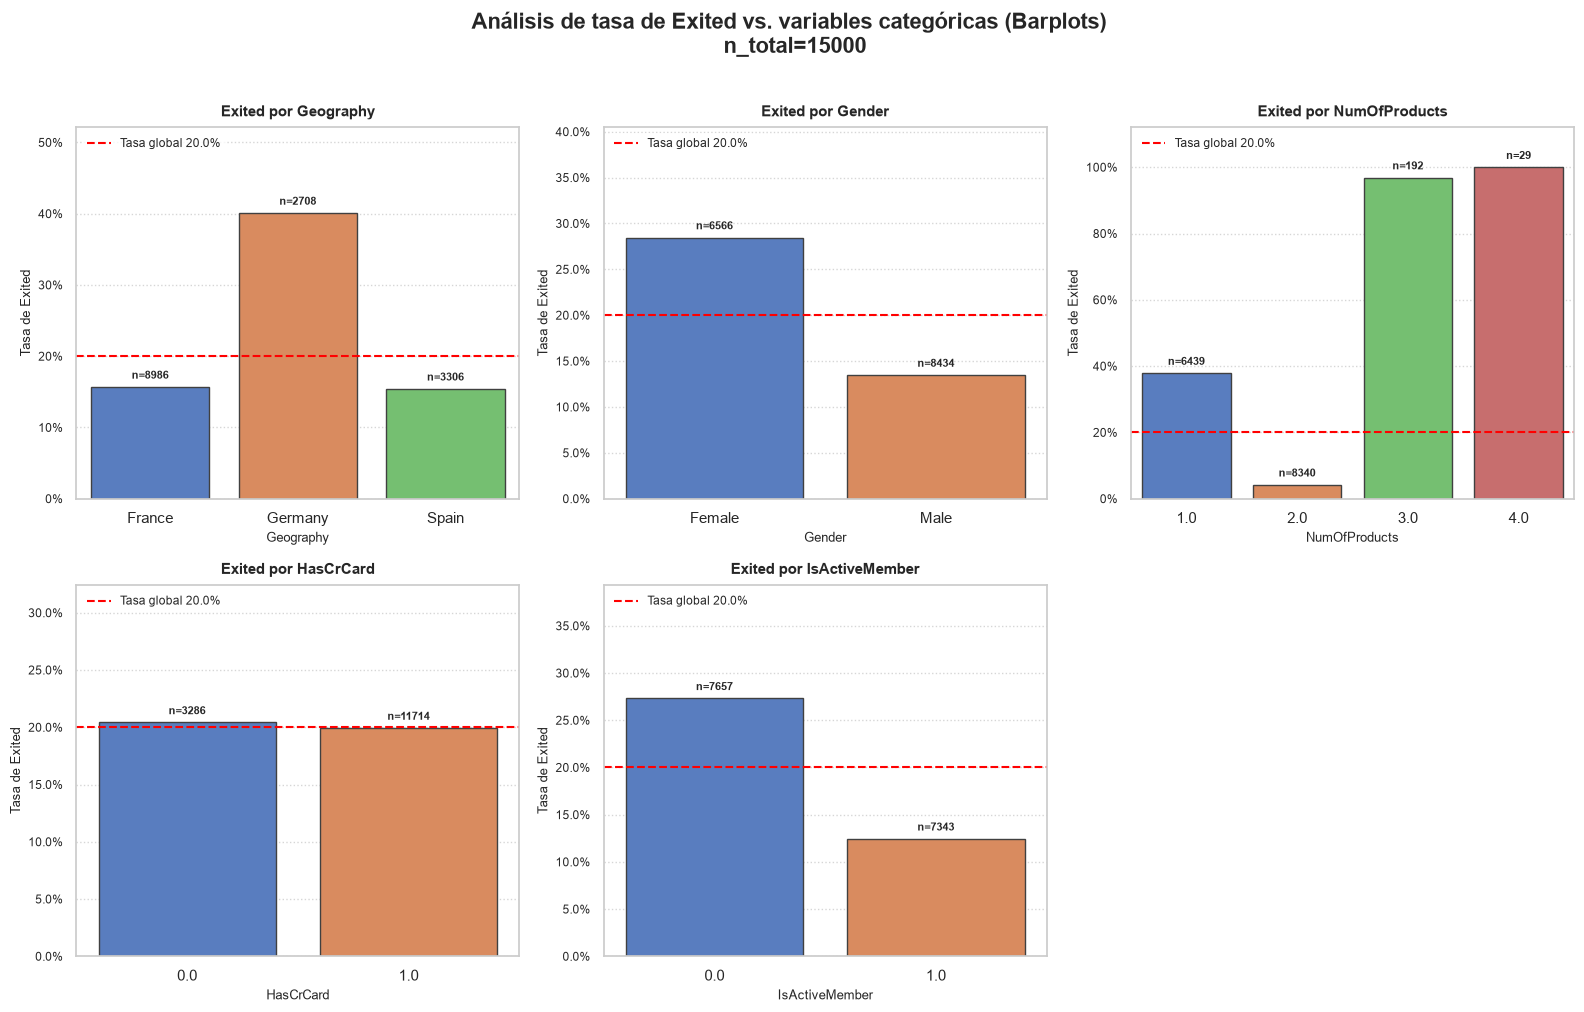

In [ ]:
# 08. REALIZAR ANALISIS DE TASA DE ABANDONO VS VARIABLES CATEGORICAS / BINARIAS (BARPLOTS)

import matplotlib.ticker as mtick

# Definimos las variables categóricas o binarias a analizar
variables_a_graficar = [
    'Geography',
    'Gender',
    'NumOfProducts',
    'HasCrCard',
    'IsActiveMember'
 ]

# Calculamos la tasa base real del dataset
tasa_base = df_depurado[target].mean()

# Configuramos el estilo estético de Seaborn
sns.set_theme(style="whitegrid")

# Creamos una grilla de 2 filas y 3 columnas
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes_flat = axes.flat

for i, var in enumerate(variables_a_graficar):
    ax = axes_flat[i]
    ax.grid(False)

    # Tasa de churn y tamaño muestral por categoría
    data_grafico = (
        df_depurado.groupby(var)[target]
        .agg(tasa='mean', n='size')
        .reset_index()
    )

    orden_categorias = data_grafico[var].tolist()

    sns.barplot(
        x=var,
        y='tasa',
        data=data_grafico,
        order=orden_categorias,
        hue=var,
        hue_order=orden_categorias,
        palette="muted",
        legend=False,
        edgecolor='#404040',
        ax=ax
    )

    linea_base = ax.axhline(
        y=tasa_base,
        color='red',
        linestyle='--',
        linewidth=1.5
    )

    ax.legend(
        [linea_base],
        [f'Tasa global {tasa_base*100:.1f}%'],
        loc='upper left',
        fontsize=8.5,
        frameon=True,
        facecolor='white',
        edgecolor='none'
    )

    ax.set_title(f"Exited por {var}", fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel(var, fontsize=9)
    ax.set_ylabel("Tasa de Exited", fontsize=9)

    max_val = data_grafico['tasa'].max()
    ax.set_ylim(0, max_val + 0.12 if max_val > 0 else 0.3)

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.tick_params(axis='y', labelsize=8.5)
    ax.grid(axis='y', linestyle=':', alpha=0.8)

    # Etiquetas: solo tamaño muestral
    for j, p in enumerate(ax.patches):
        height = p.get_height()
        if height > 0 and j < len(data_grafico):
            n_cat = int(data_grafico.iloc[j]['n'])
            ax.annotate(
                f"n={n_cat}",
                (p.get_x() + p.get_width() / 2.0, height),
                ha='center',
                va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize=8,
                fontweight='bold'
            )

# Apagamos cuadrantes vacíos
for j in range(len(variables_a_graficar), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle(f"Análisis de tasa de Exited vs. variables categóricas (Barplots) \n n_total={len(df_depurado)}", y=1.01, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### Observaciones primarias sobre los barplots de variables categóricas

* a) _NumOfProducts_ discrepancia extremadamente clara de 3 y 4 con el resto, pero muy poco peso muestral
* b) _Gender_ y _ActiveMember_ muy similares y con alto peso muestral en ambos valores por lo que se muestran como muy interesantes
* c) _HasCrCard_ no parece decirnos mucho por sí sola

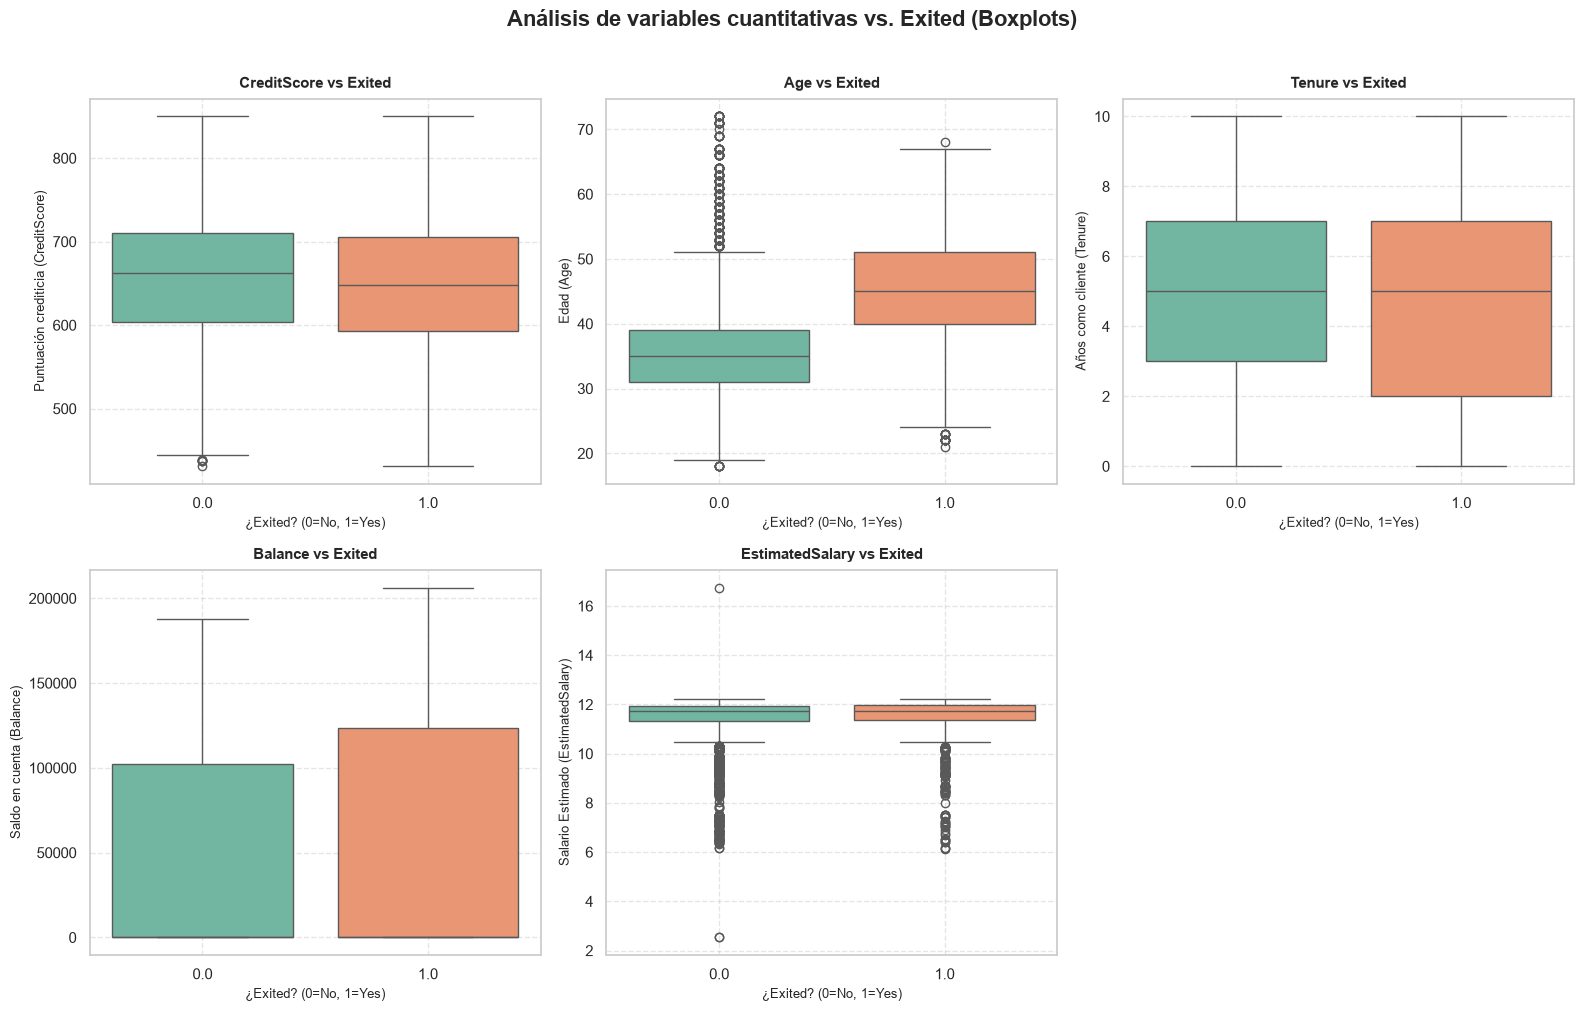

In [ ]:
# 10. REALIZAR ANALISIS DE VARIABLES NUMERICAS VERSUS EXITED (BOXPLOTS)

# Definimos las variables numéricas a analizar
variables_boxplot = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'EstimatedSalary'
]

# Configuramos el estilo estético de Seaborn
sns.set_theme(style="whitegrid")

# Redefinimos el tamaño de la figura a un formato ideal (16 de base x 10 de alto)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))

# Aplanamos la matriz de 2x3 para iterar linealmente del 0 al 5
axes_flat = axes.flat

# Mapeamos títulos amigables en español
titulos = {
    'CreditScore': 'Puntuación crediticia (CreditScore)',
    'Age': 'Edad (Age)',
    'Tenure': 'Años como cliente (Tenure)',
    'Balance': 'Saldo en cuenta (Balance)',
    'EstimatedSalary': 'Salario Estimado (EstimatedSalary)'
}

# Iteramos para construir cada Boxplot
for i, var in enumerate(variables_boxplot):
    ax = axes_flat[i]

    sns.boxplot(
        x=target,
        y=var,
        data=df_depurado,
        ax=ax,
        palette="Set2",
        hue=target,
        legend=False
    )

    # Adaptamos títulos y etiquetas al ancho de las 2 columnas
    ax.set_title(f"{var} vs Exited", fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel("¿Exited? (0=No, 1=Yes)", fontsize=9)
    ax.set_ylabel(titulos.get(var, var), fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

# Apagamos cuadrantes vacíos
for j in range(len(variables_boxplot), len(axes_flat)):
    axes_flat[j].axis('off')

# Generamos título general, ajustamos layout y mostramos
plt.suptitle("Análisis de variables cuantitativas vs. Exited (Boxplots)", y=1.01, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

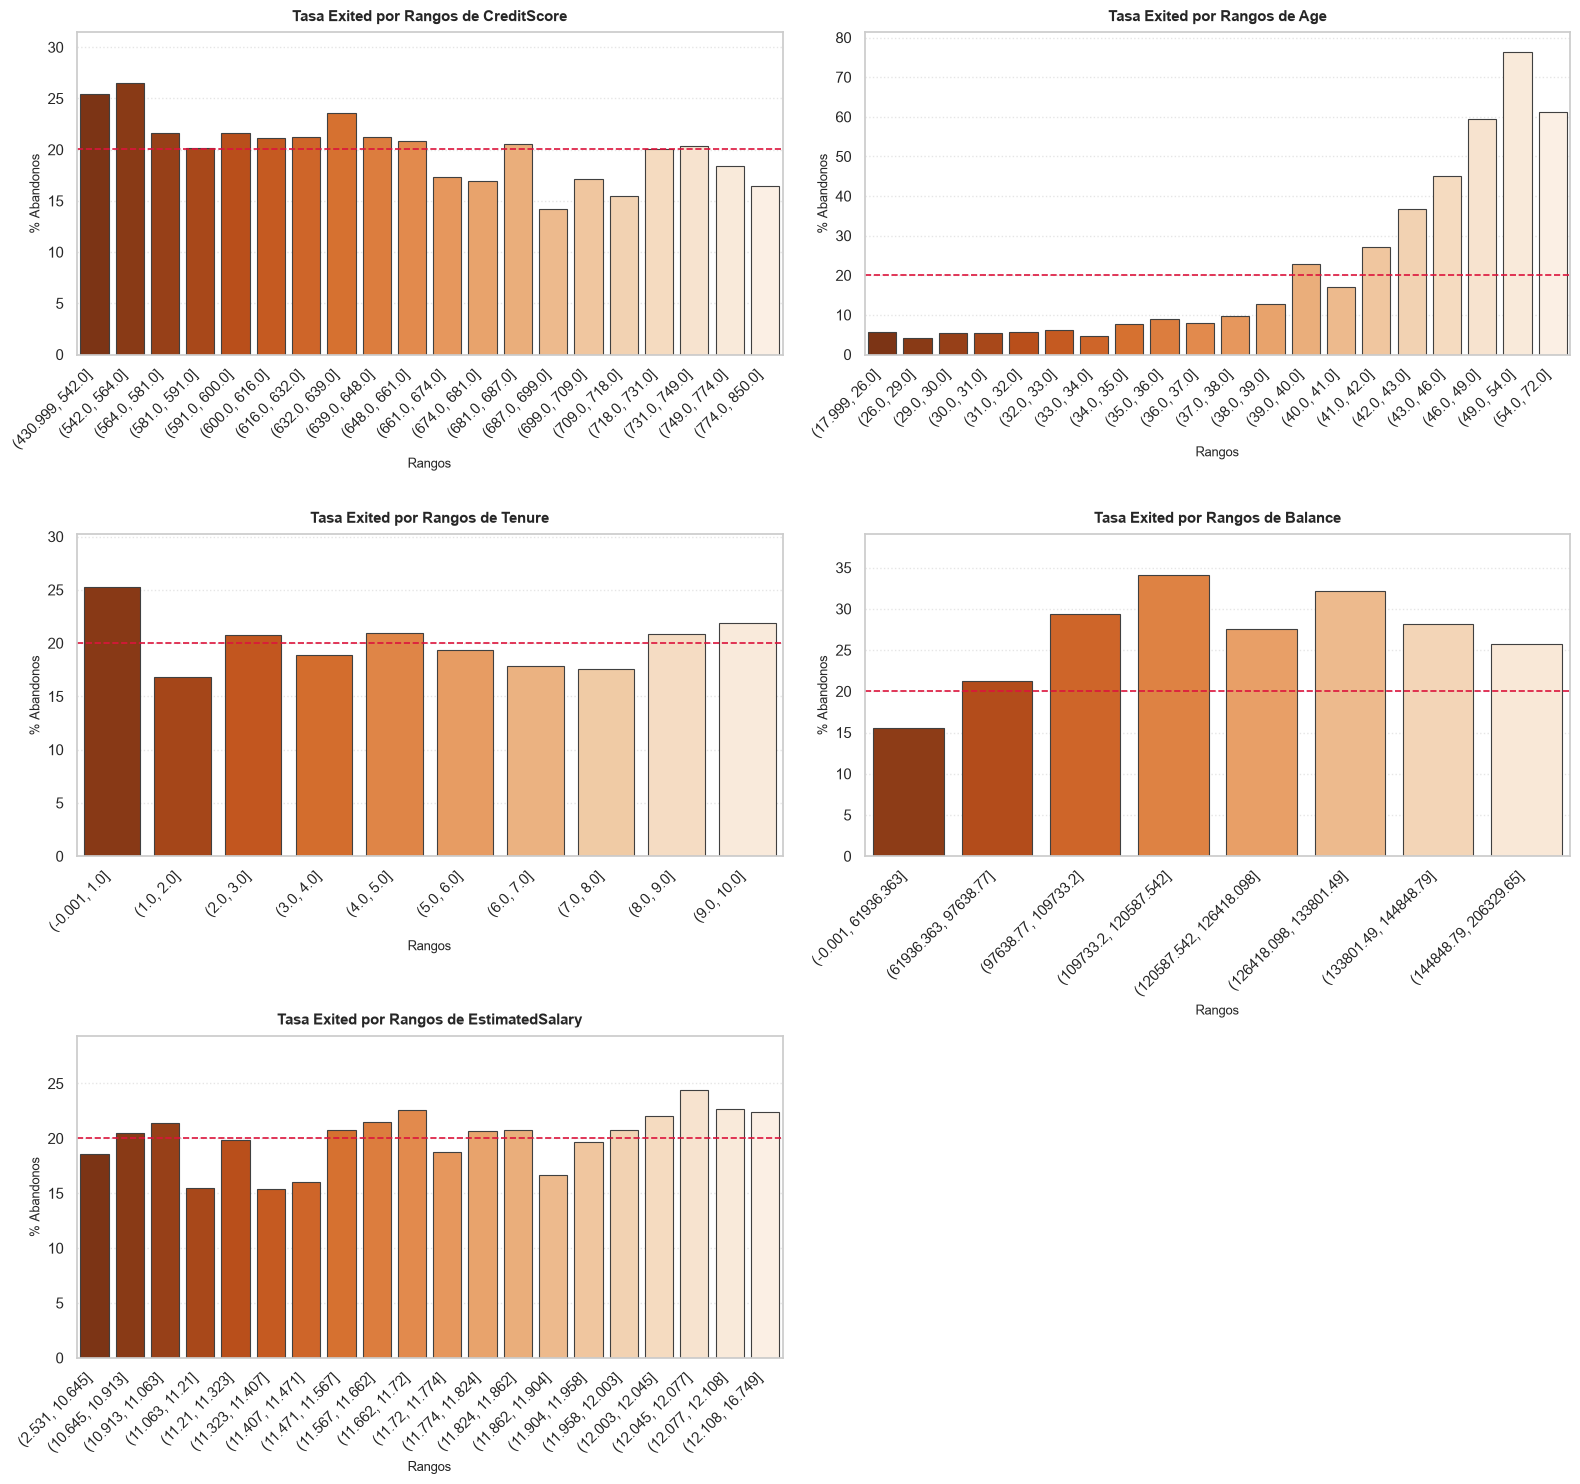

In [ ]:
# 11. REALIZAR BARPLOTS DE TASA DE EXITED POR RANGOS DE VARIABLES NUMERICAS

import math
# Hacemos lo mismo pero para las variables numericas, pero a estas las tendremos que dividir en rangos para los graficos de barras. 

n_cols = 2
# Calculamos las filas necesarias de forma dinámica
n_rows = math.ceil(len(num_features) / n_cols) 

# Creamos la copia de trabajo y pasamos el target a porcentaje directo (0 a 100%)
df_plot = df_depurado.copy()
df_plot['Exited_Percent'] = df_plot['Exited'].map({1: 100, 0: 0})

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))

# Aplanamos el array de ejes para poder iterar en un solo bucle limpio (aplasta una matriz 2D en 1D)
axes = axes.flatten()

# ==================================================================================================
# BUCLE EN MATRIZ DE SUBPLOTS
# ==================================================================================================
for i, var in enumerate(num_features):
    ax = axes[i]
    col_intervalo = f'{var}_Rango'
    
    # Segmentamos la variable numérica continua en 10 deciles
    # Usamos duplicates='drop' por seguridad si hay muchos valores idénticos (por lo que algunas variables no quedaran con 10 rangos)
    df_plot[col_intervalo] = pd.qcut(df_plot[var], q=20, duplicates='drop')

    data_tasa_num = (
        df_plot.groupby(col_intervalo, observed=True)['Exited_Percent']
        .mean()
        .sort_index()
        .reset_index()
    )

    data_tasa_num[col_intervalo] = data_tasa_num[col_intervalo].astype(str)
    
    # Dibujamos el barplot en el eje correspondiente
    sns.barplot(
        x=col_intervalo, 
        y='Exited_Percent', 
        data=data_tasa_num, 
        palette='Oranges_r',
        hue=col_intervalo,
        legend=False,
        ax=ax,
        edgecolor='#404040', 
        linewidth=0.8
    )
    
    # Añadimos la línea roja con la tasa base del 16% global de la empresa
    ax.axhline(y=20.04, color='crimson', linestyle='--', linewidth=1.2, label='Base Global (20.04%)' if i == 0 else "")
    
    ax.set_title(f'Tasa Exited por Rangos de {var}', fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Rangos', fontsize=9) 
    ax.set_ylabel('% Abandonos', fontsize=9)
    ax.set_ylim(0, max(data_tasa_num['Exited_Percent'].max() + 5, 25))
    ax.grid(axis='y', linestyle=':', alpha=0.5)

    ax.tick_params(axis='x', rotation=45)
    for tick in ax.get_xticklabels():
        tick.set_horizontalalignment('right')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.show()

#### Como los barplots parece que describen bastante bien a las categóricas y no suman mucho en la matriz de correlación, las sacamos y dejamos solo las numéricas que sí son faciles de interpretar

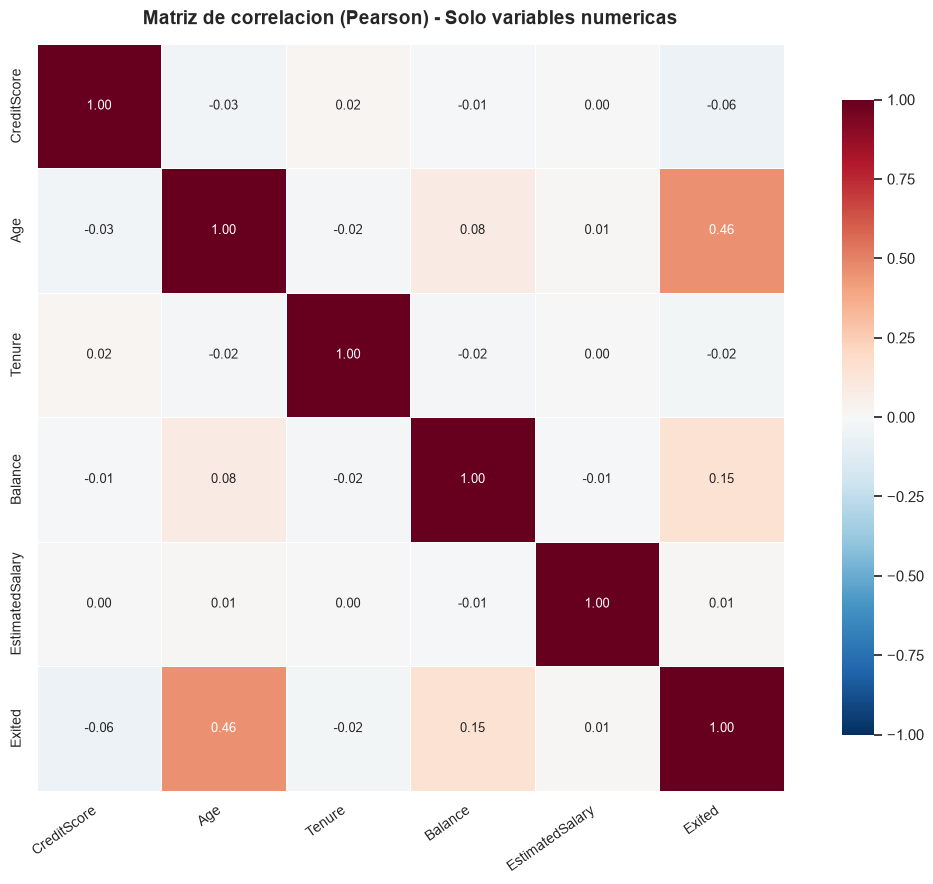

findfont: Failed to find font weight semibold, now using 700.


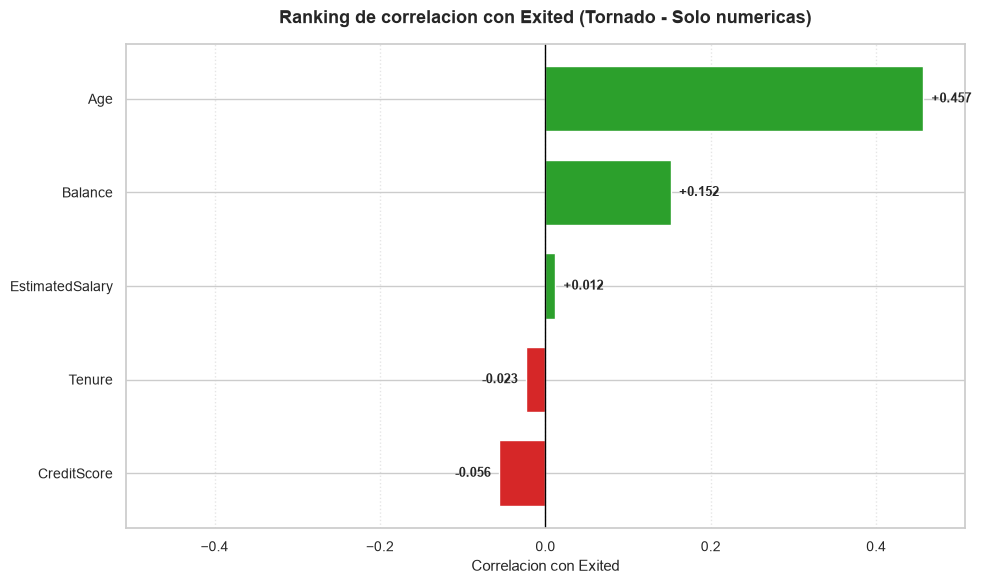

In [ ]:
# 13. MATRIZ DE CORRELACION (EDA SOLO NUMERICAS) + RANKING TORNADO

# Correlación solo con variables numericas del modelo + target
df_eda_corr_num = df_depurado[num_features + [target]].copy()
corr_eda = df_eda_corr_num.corr(numeric_only=True)

# Reordenar para dejar Exited al final (última fila y última columna)
if target in corr_eda.columns:
    cols_ordenadas = [c for c in corr_eda.columns if c != target] + [target]
    corr_eda = corr_eda.loc[cols_ordenadas, cols_ordenadas]

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_eda,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.85},
    annot_kws={'size': 9}
 )
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.title('Matriz de correlación (Pearson) - Solo variables numéricas', fontsize=14, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

# Ranking de correlación con el target en modo tornado
corr_target_eda = corr_eda[target].drop(target)

# Positivas arriba y negativas abajo
ranking_pos = corr_target_eda[corr_target_eda >= 0].sort_values(ascending=False)
ranking_neg = corr_target_eda[corr_target_eda < 0].sort_values(ascending=False)
ranking_eda = pd.concat([ranking_pos, ranking_neg])

fig, ax = plt.subplots(figsize=(10, 6))
colores = ['#2ca02c' if v >= 0 else "#d62728" for v in ranking_eda.values]

ax.barh(ranking_eda.index, ranking_eda.values, color=colores, height=0.7)
ax.axvline(0, color='black', linewidth=1.0)
ax.invert_yaxis()
ax.set_xlabel('Correlacion con Exited', fontsize=11)
ax.set_title('Ranking de correlación con Exited (Tornado - Solo numéricas)', fontweight='bold', fontsize=13, pad=15)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)

for i, v in enumerate(ranking_eda.values):
    offset = 0.01 if v >= 0 else -0.01
    align = 'left' if v >= 0 else 'right'
    ax.text(v + offset, i, f'{v:+.3f}', va='center', ha=align, fontsize=9, fontweight='semibold')

lim = max(abs(ranking_eda.min()), abs(ranking_eda.max())) + 0.05
ax.set_xlim(-lim, lim)
ax.grid(axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

## 3) Feature Engineering

In [ ]:
# 13. COMPLETAR POR GRUPOS LISTA DE VARIABLES A USAR EN EL MODELO

# Definimos variables numéricas a usar en el modelo
num_features = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'EstimatedSalary'
]

# Definimos variables categóricas a usar en el modelo
cat_features = [
    'Geography',
    'Gender',
    'NumOfProducts'

]

# Definimos variables binarias a usar en el modelo
bin_features = [
    'HasCrCard',
    'IsActiveMember'
]

target = 'Exited'

## 4) Column transformer
### Instanciamos la imputación y la transormación que tendrá cada variable

In [ ]:
# 14. CONSTRUIR COLUMN TRANSFORMER

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Imputamos por la mediana y escalamos las variables numéricas
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Imputamos por la moda y codificamos las variables categóricas
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

# Imputamos por la moda las variables binarias
binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

# Construimos el ColumnTransformer combinando los tres pipelines anteriores
preprocesador = ColumnTransformer(
    transformers=[
        ('escalar_num', numeric_transformer, num_features),
        ('codificar_cat', categorical_transformer, cat_features),
        ('imputar_bin', binary_transformer, bin_features),
    ],
    remainder='drop'
)

## 5) División del dataset entre train y test 

In [ ]:
# 15. DIVISION DEL DATASET EN CONJUNTO DE ENTRENAMIENTO Y PRUEBA

from sklearn.model_selection import train_test_split

X = df_depurado.drop(columns=[target])
y = df_depurado[target]

# Obtenemos dataset de entrenamiento y testeo con dataset desbalanceado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)  # stratify=y porque dataset desbalanceado

# Mostramos dataset completo sin variable respuesta
display(X)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,636.00,France,Male,36.00,9.00,0.00,1.00,1.00,1.00,10.89
1,742.00,France,Male,35.00,1.00,0.00,2.00,1.00,1.00,10.95
2,704.00,France,Female,38.00,5.00,161889.79,1.00,1.00,0.00,11.29
3,685.00,France,Female,38.00,0.00,0.00,2.00,1.00,0.00,11.38
4,708.00,France,Male,34.00,10.00,0.00,2.00,0.00,0.00,11.07
...,...,...,...,...,...,...,...,...,...,...
14995,580.00,Germany,Female,37.00,3.00,141806.00,2.00,1.00,0.00,11.93
14996,516.00,Spain,Female,38.00,4.00,0.00,2.00,1.00,0.00,12.05
14997,538.00,Germany,Female,43.00,7.00,129745.10,1.00,1.00,0.00,7.25
14998,616.00,France,Female,27.00,7.00,0.00,2.00,0.00,1.00,11.50


## 6) Entrenamiento de los distintos modelos 
### En esta seccion entrenaremos 3? modelos de machine leraning para atacar el problema, obteniendo un submission_modelo_X.csv para cada uno de ellos y sus respectivas metricas con la parte de test que dejamos del dataset train.csv

### Los modelos que entrenaremos son los siguientes: 
* a) Random Forest
* b) Regresión Logistica 
* c) Red Neuronal 

### 6.a) Random Forest 

In [15]:

# 17. ENTRENAR RANDOM FOREST CON PIPELINE Y GRIDSEARCHCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

pipe_rf = Pipeline(steps=[
    ('pre', preprocesador),
    ('clf', RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2'],
    'clf__class_weight': ['balanced']
}

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print(f"Mejores parámetros (RF): {grid_rf.best_params_}")
print(f"Mejor ROC-AUC (RF):      {grid_rf.best_score_:.4f}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Mejores parámetros (RF): {'clf__class_weight': 'balanced', 'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}
Mejor ROC-AUC (RF):      0.9282


In [16]:
# 18. EVALUAR EL MODELO RANDOM FOREST USANDO EL SUBSET DE TEST DE TRAIN.CSV

from sklearn.metrics import auc

y_pred = grid_rf.best_estimator_.predict(X_test)

auc = roc_auc_score(y_test, grid_rf.best_estimator_.predict_proba(X_test)[:, 1])
print(f"\n{'='*53}")
print(f"(ROC-AUC RF test = {auc:.4f})")
print(f"{'='*53}")
print(classification_report(y_test, y_pred))    


(ROC-AUC RF test = 0.9246)
              precision    recall  f1-score   support

         0.0       0.95      0.88      0.91      2399
         1.0       0.62      0.82      0.71       601

    accuracy                           0.87      3000
   macro avg       0.79      0.85      0.81      3000
weighted avg       0.89      0.87      0.87      3000



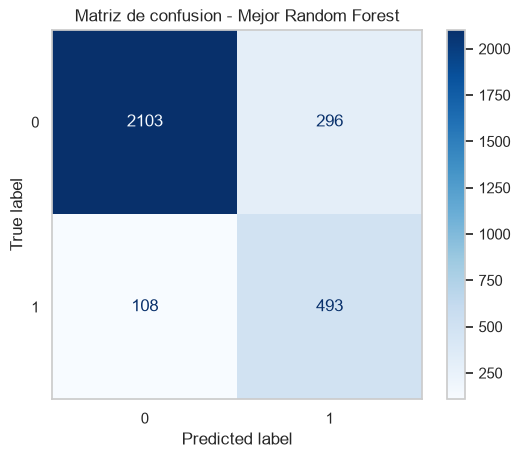

In [ ]:
# Matriz de confusión

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

best_rf_model = grid_rf.best_estimator_

y_pred_best = best_rf_model.predict(X_test)
y_proba_best = best_rf_model.predict_proba(X_test)[:, 1]

cm_best = confusion_matrix(y_test, y_pred_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best)
disp_best.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusión - Mejor Random Forest')
plt.grid(False)
plt.show()

### 6.c) Red Neuronal 

In [ ]:
# 11. BUSQUEDA DE HIPERPARAMETROS PARA MLP

from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

nn_pipe = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('mlp', MLPClassifier(
        random_state=42,
        max_iter=400,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20
    ))
])

param_dist = {
    'mlp__hidden_layer_sizes': [(32,), (64,), (64, 32), (14, 7, 32), (32, 16, 8), (64, 32, 16), (16, 8, 4), (16, 8, 4, 2)],
    'mlp__activation': ['relu'],
    'mlp__alpha': [1e-4, 1e-3, 1e-2, 0.1, 1],
    'mlp__learning_rate_init': [1e-4, 5e-4, 1e-3, 5e-3],
    'mlp__batch_size': [8, 16, 32, 64, 128]
}

nn_search = RandomizedSearchCV(
    estimator=nn_pipe,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    n_jobs=7,
    verbose=1,
    random_state=42
)

nn_search.fit(X_train, y_train)

print('Mejor AUC CV:', round(nn_search.best_score_, 4))
print('Mejores hiperparametros:')
for k, v in nn_search.best_params_.items():
    print(f'  - {k}: {v}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejor AUC CV: 0.9294
Mejores hiperparametros:
  - mlp__learning_rate_init: 0.005
  - mlp__hidden_layer_sizes: (64,)
  - mlp__batch_size: 8
  - mlp__alpha: 0.01
  - mlp__activation: relu


### Resultado de la búsqueda de hiperparámetros:

#### En las pruebas realizadas, el mejor modelo quedó con 3 capas con la estructura **(16, 8, 4)**. 

Mejor AUC CV: 0.9292
  - mlp__learning_rate_init: 0.001

  (es el tamaño del paso que realiza entre iteraciones para cambiar los pesos de las neuronas en la busqueda por descenso de gradiente, más pequeño significa mas presicion pero lentitud y posibilidad de quedar atrapado en minimos locales, mientras que grandes pueden escapar mas facilmente y son mas rapidos pero se pueden escapar de la solucion ideal con mas facilidad y oscilar mucho o ni siquiera converger)

  - mlp__hidden_layer_sizes: (16, 8, 4)

  (son tres capas, la primera con 16 neuronas, la segunda con 8 y la tercera con 4)

  - mlp__batch_size: 8

  (es el numero de observaciones que utiliza para calcular el gradiente, mientras mas pequeño mas ruido puede introducir pero puede servir para escapar minimos locales y generalizar mejor, mas grandes pueden mapear mejor el gradiente pero tambien corren el riesgo de no poder escapar minimos locales)

  - mlp__alpha: 0.01

  (es el termino de penalizacion para los pesos excesivamente grandes en la funcion de pérdida, mientras mas grandes, mas penalizacion y por lo tanto mayor reduccion del overfitting)

  - mlp__activation: relu

  (funcion de activacion de las neuronas para poder introducir no linealidad, ni siquiera probé con otra por lo que nos ha contado el profesor de que relu es la mejor)

AUC ROC (test) - mejor modelo: 0.9252

Classification Report (mejor modelo):
              precision    recall  f1-score   support

         0.0       0.92      0.97      0.94      2399
         1.0       0.83      0.66      0.73       601

    accuracy                           0.90      3000
   macro avg       0.87      0.81      0.84      3000
weighted avg       0.90      0.90      0.90      3000



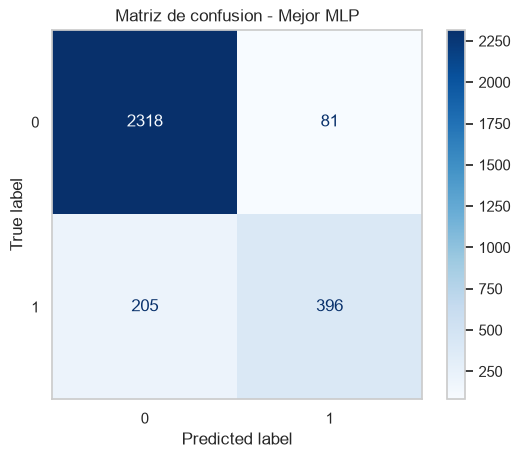

In [19]:
# 12. EVALUAR EL MEJOR MODELO EN TEST
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

best_nn_model = nn_search.best_estimator_

y_pred_best = best_nn_model.predict(X_test)
y_proba_best = best_nn_model.predict_proba(X_test)[:, 1]

print('AUC ROC (test) - mejor modelo:', round(roc_auc_score(y_test, y_proba_best), 4))
print('\nClassification Report (mejor modelo):')
print(classification_report(y_test, y_pred_best))

cm_best = confusion_matrix(y_test, y_pred_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best)
disp_best.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusion - Mejor MLP')
plt.grid(False)
plt.show()

## 7) Permutation Importance
### Estudio posterior al ajuste del modelo para evaluar que tan importante es cada variable en la prediccion. El metodo se basa en randomizar una sola variable y ver como eso afecta al resultado final realizando nuevas predicciones. Esto se repite 10 veces para cada variable para calcular la media y la varianza y para cada variable. 

Calculando Permutation Importance (esto puede tomar unos segundos)...


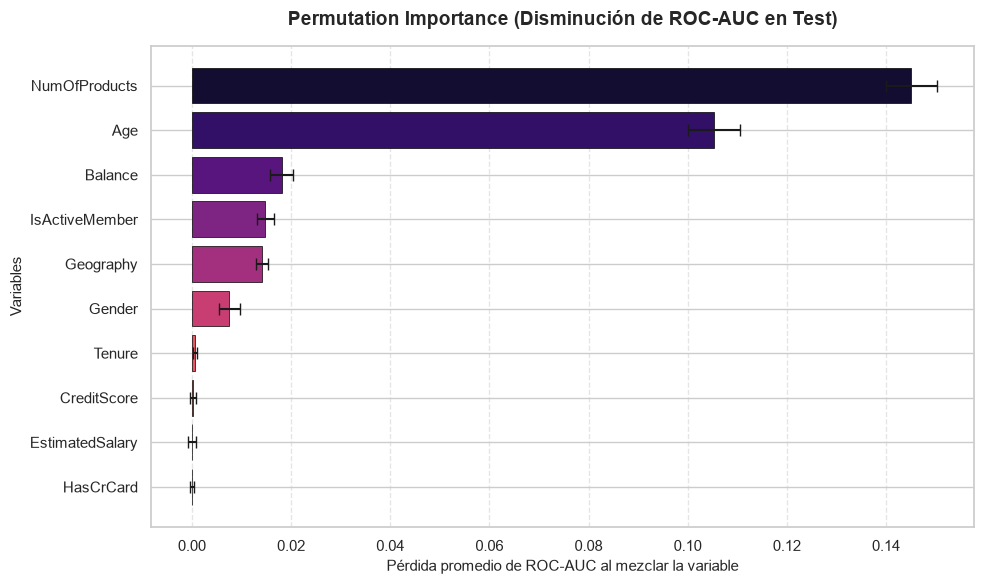

Ranking numérico de impacto:


,Variable,Importancia_Media,Desviacion_Estandar
6,NumOfProducts,0.15,0.01
3,Age,0.11,0.01
5,Balance,0.02,0.00
8,IsActiveMember,0.01,0.00
1,Geography,0.01,0.00
2,Gender,0.01,0.00
4,Tenure,0.00,0.00
0,CreditScore,0.00,0.00
9,EstimatedSalary,0.00,0.00
7,HasCrCard,0.00,0.00


In [20]:
# 19. REALIZAR ANALISIS DE IMPORTANCIA DE VARIABLES (PERMUTATION IMPORTANCE)

from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Calculando Permutation Importance (esto puede tomar unos segundos)...")

# 1. Ejecutar Permutation Importance
# Usamos el mejor modelo (best_estimator_) sobre los datos de prueba
resultado_permutacion = permutation_importance(
    estimator=grid_rf.best_estimator_,
    X=X_test,
    y=y_test,
    scoring='roc_auc',  # Usamos la misma métrica que en GridSearchCV
    n_repeats=10,       # Cantidad de veces que se mezcla cada columna para promediar
    random_state=42,
    n_jobs=-1           # Usa todos los procesadores disponibles
)

# 2. Consolidar los resultados en un DataFrame
df_importancia = pd.DataFrame({
    'Variable': X_test.columns,
    'Importancia_Media': resultado_permutacion.importances_mean,
    'Desviacion_Estandar': resultado_permutacion.importances_std
})

# Ordenar las variables de mayor a menor importancia
df_importancia = df_importancia.sort_values(by='Importancia_Media', ascending=False)

# 3. Visualizar los resultados con un Barplot
plt.figure(figsize=(10, 6))

# Usamos matplotlib puro (plt.barh) que maneja perfectamente los errores pre-calculados (xerr)
plt.barh(
    y=df_importancia['Variable'],
    width=df_importancia['Importancia_Media'],
    xerr=df_importancia['Desviacion_Estandar'],
    capsize=4,
    color=sns.color_palette('magma', len(df_importancia)),
    edgecolor='black',
    linewidth=0.5
)

# Invertir el eje Y para que la variable más importante quede en la parte superior
plt.gca().invert_yaxis()

plt.title('Permutation Importance (Disminución de ROC-AUC en Test)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Pérdida promedio de ROC-AUC al mezclar la variable', fontsize=11)
plt.ylabel('Variables', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Mostrar la tabla exacta en pantalla
print("Ranking numérico de impacto:")
display(df_importancia)

## 8) Submission
### Generar los archivos para realizar el submission a Kaggle. 

In [21]:
# 20. IMPORTAR DATASET test.csv

url_test = "https://raw.githubusercontent.com/estebancardoso96/grupo_3/main/test.csv"
df_test = pd.read_csv(url_test)

In [22]:
# 21. REALIZAR UNA INSPECCION INICIAL DEL DATASET test.csv ---

print("AUDITORIA DE VARIABLES DEL DATASET test.csv")

print(f"\nDimensiones del dataset: {df_test.shape[0]} filas × {df_test.shape[1]} columnas\n")

audit = pd.DataFrame({
    'dtype':          df_test.dtypes,
    'nulos':          df_test.isnull().sum(),
    'pct_nulos':      (df_test.isnull().sum() / len(df_test) * 100).round(2),
    'valores_únicos': df_test.nunique(),
    'moda':           df_test.mode().iloc[0], # Extrae la primera fila de la moda
    'ejemplo':        df_test.sample(1).iloc[0], # Genera muestra aleatoria y extrae primera fila
    })
audit

AUDITORIA DE VARIABLES DEL DATASET test.csv

Dimensiones del dataset: 10000 filas × 13 columnas



,dtype,nulos,pct_nulos,valores_únicos,moda,ejemplo
id,int64,0,0.00,10000,15000,20328
CustomerId,float64,0,0.00,5224,15593365.00,15736327.00
Surname,str,0,0.00,711,Ch'iu,Tseng
CreditScore,float64,0,0.00,366,678.00,850.00
Geography,str,0,0.00,3,France,Spain
Gender,str,0,0.00,2,Male,Male
Age,float64,0,0.00,55,37.00,35.00
Tenure,float64,0,0.00,11,2.00,6.00
Balance,float64,0,0.00,2502,0.00,0.00
NumOfProducts,float64,0,0.00,4,2.00,2.00


In [23]:
# 22. GENERAR SAMPLE SUBMISSION DE test.csv PARA MODELO BASE DE RANDOM FOREST ---

# Eliminar en test.csv las mismas columnas que se descartaron en train.csv
df_test_depurado = df_test.drop(columns=col_eliminar)

# Generar las probabilidades de abandono (Exited) usando el mejor modelo entrenado
y_test_prob = grid_rf.best_estimator_.predict_proba(df_test_depurado)[:, 1]

# Crear un DataFrame con el 'id' original y la probabilidad generada
df_resultados = pd.DataFrame({
    'id': df_test['id'],
    'Exited': y_test_prob
})

# Visualizar las primeras filas para comprobar la estructura
print("Vista previa de las probabilidades:")
print(df_resultados.head())

# Exportar las probabilidades a un archivo CSV sin incluír el índice
df_resultados.to_csv('submission_modelo_base_rf.csv', index=False)
print("\nArchivo 'submission_modelo_base_rf.csv' exportado exitosamente.")

Vista previa de las probabilidades:
      id  Exited
0  15000    0.13
1  15001    0.78
2  15002    0.16
3  15003    0.91
4  15004    0.26

Archivo 'submission_modelo_base_rf.csv' exportado exitosamente.


In [ ]:
# 23. GENERAR SAMPLE SUBMISSION DE test.csv PARA MODELO BASE DE RED NEURONAL ---

# Eliminar en test.csv las mismas columnas que se descartaron en train.csv
df_test_depurado = df_test.drop(columns=col_eliminar)

# Generar las probabilidades de abandono (Exited) usando el mejor modelo entrenado
y_test_prob = nn_search.best_estimator_.predict_proba(df_test_depurado)[:, 1]

# Crear un DataFrame con el 'id' original y la probabilidad generada
df_resultados = pd.DataFrame({
    'id': df_test['id'],
    'Exited': y_test_prob
})

# Visualizar las primeras filas para comprobar la estructura
print("Vista previa de las probabilidades:")
print(df_resultados.head())

# Exportar las probabilidades a un archivo CSV sin incluír el índice
df_resultados.to_csv('submission_modelo_base_nn.csv', index=False)
print("\nArchivo 'submission_modelo_base_nn.csv' exportado exitosamente.")